# Camera Transformations

In [13]:
import pytorch3d.structures
import pytorch3d.io
import pytorch3d.renderer
import torch
import numpy
import imageio
from matplotlib import pyplot as plt
from starter.utils import get_mesh_renderer

In [14]:
mesh = pytorch3d.io.load_objs_as_meshes(["data/cow.obj"])
renderer = get_mesh_renderer(image_size=500, device='cpu')

In [16]:
# Original rotation and translation matrices
R_0 = torch.Tensor(
    [
        [1.0, 0, 0],
        [0, 1, 0],
        [0, 0, 1]
    ]
)
T_0 = torch.Tensor(
    [0, 0, 3.0] # z-forward
)

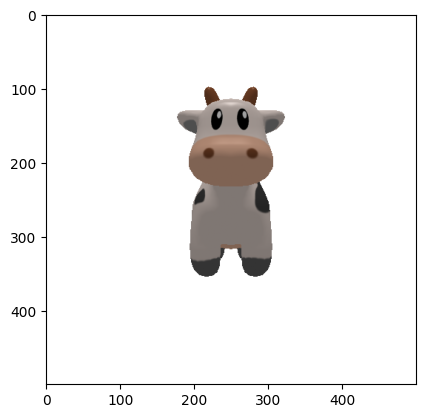

In [23]:
# try render this out
cameras = pytorch3d.renderer.FoVPerspectiveCameras(
    R=R_0.unsqueeze(0),
    T=T_0.unsqueeze(0),
)

lights = pytorch3d.renderer.DirectionalLights()

rend = renderer(mesh, cameras=cameras, lights=lights)
plt.plot(figsize=(10, 10))
plt.imshow(rend[0, ..., :3])

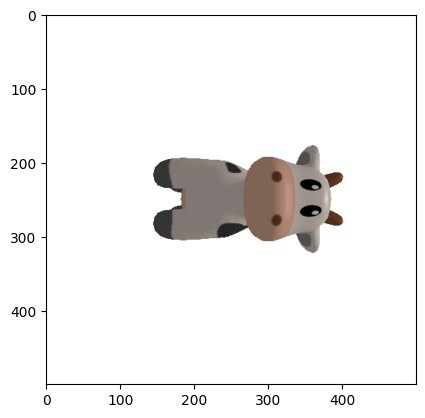

In [32]:
# spinning the camera around
# fig 1: roll -90 deg
import math
R_roll = torch.Tensor([
    [math.cos(-math.pi / 2), -math.sin(-math.pi / 2), 0],
    [math.sin(-math.pi / 2), math.cos(-math.pi / 2), 0],
    [0, 0, 1]
])

R_rel = R_roll @ torch.eye(3) @ torch.eye(3)

# try render this out
cameras = pytorch3d.renderer.FoVPerspectiveCameras(
    R=(R_rel @ R_0).unsqueeze(0),
    T=T_0.unsqueeze(0),
)

lights = pytorch3d.renderer.DirectionalLights()

rend = renderer(mesh, cameras=cameras, lights=lights)
plt.plot(figsize=(10, 10))
plt.imshow(rend[0, ..., :3])

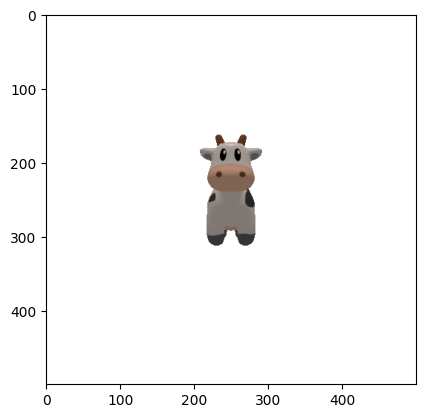

In [44]:
# cow from afar

R_rel = torch.eye(3)
T_rel = torch.Tensor([0, 0, 2])

# try render this out
cameras = pytorch3d.renderer.FoVPerspectiveCameras(
    R=(R_rel @ R_0).unsqueeze(0),
    T=(R_rel @ T_0 + T_rel).unsqueeze(0),
)
lights = pytorch3d.renderer.DirectionalLights()

rend = renderer(mesh, cameras=cameras, lights=lights)
plt.plot(figsize=(10, 10))
plt.imshow(rend[0, ..., :3])

> In Pytorch3D's FoVPerspectiveCameras, the Rotational and Translation matrices are extrinsic. It defines where the world sits relative to the camera. Hence, increasing z-value of T actually "pushes" the world further from the camera (z-forward)

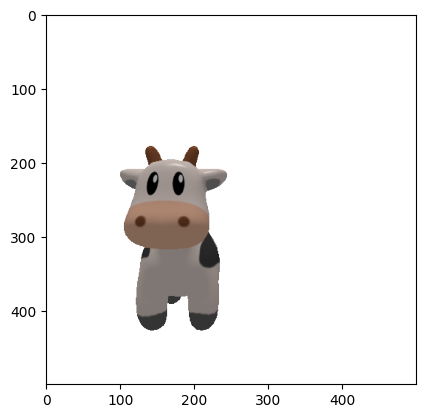

In [54]:
# Cow to the left

R_rel = torch.eye(3)
T_rel = torch.Tensor([0.5, -0.5, 0])

cameras = pytorch3d.renderer.FoVPerspectiveCameras(
    R = (R_rel @ R_0).unsqueeze(0),
    T = (R_rel @ T_0 + T_rel).unsqueeze(0)
)

lights = pytorch3d.renderer.DirectionalLights()

rend = renderer(mesh, cameras=cameras, lights=lights)

plt.plot(figsize=(10, 10))
plt.imshow(rend.squeeze(0))


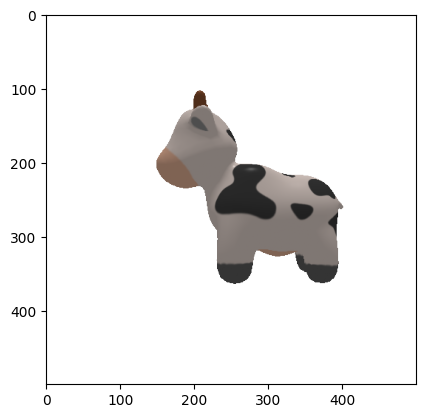

In [68]:
R_yaw = torch.Tensor(
    [
        [math.cos(math.pi/2), 0, math.sin(math.pi/2)],
        [0, 1, 0],
        [-math.sin(math.pi/2), 0, math.cos(math.pi/2)]
    ]
)

R_rel = R_yaw
T_rel = torch.Tensor([0, 0, 0])

cameras = pytorch3d.renderer.FoVPerspectiveCameras(
    R = (R_yaw).unsqueeze(0),
    T = (R_0 @ T_0 + T_rel).unsqueeze(0)
)

lights = pytorch3d.renderer.DirectionalLights()

rend = renderer(mesh, cameras=cameras, lights=lights)

plt.plot(figsize=(10, 10))
plt.imshow(rend.squeeze(0))



In [69]:
R_rel

tensor([[ 6.1232e-17,  0.0000e+00,  1.0000e+00],
        [ 0.0000e+00,  1.0000e+00,  0.0000e+00],
        [-1.0000e+00,  0.0000e+00,  6.1232e-17]])